In [222]:
import numpy as np

In [287]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_prime(x):
    return np.exp(x) / ((1 + np.exp(x))**2)

def ReLU(x):
    return np.clip(x, 0., 1.)

def ReLU_prime(x):
    return np.where(x > 0, 1, 0)

def linear(x):
    return x

def linear_prime(x):
    return np.ones_like(x)

class InferenceMachine():

    def __init__(self, w, b, act, act_prime) -> None:
        self.w = w
        self.b = b
        self.act = act
        self.act_prime = act_prime

    def bengio_energy(self, n):
        inter = 0.5*np.sum(self.w * self.act(n)[:-1, :, np.newaxis] * self.act(n)[1:, np.newaxis, :])
        en = np.sum(self.b * self.act(n))
        norm = 0.5*np.sum(n**2)

        return norm - inter - en

    def hopfield_energy(self, n):
        inter = -0.5*np.sum(self.w * self.act(n)[:-1, :, np.newaxis] * self.act(n)[1:, np.newaxis, :])
        en = -1.0*np.sum(self.b * self.act(n))

        return inter + en

    def hopfield_grad(self, n):
        grad = np.zeros_like(n)
        act_n = self.act(n)
        act_prime_n = self.act_prime(n)
        grad -= self.b * act_prime_n
        if np.shape(n)[0] > 1:
            grad[:-1] -= 0.5 * act_prime_n[:-1] * np.einsum("ik,ijk->ij", act_n[1:], self.w + self.w.transpose(0, 2, 1))
            grad[1:] -= 0.5 * act_prime_n[1:] * np.einsum("ik,ijk->ij", act_n[:-1], self.w + self.w.transpose(0, 2, 1))
        else:
            grad = np.zeros_like(n)
            
        return grad

    def bengio_grad(self, n):
        grad = np.zeros_like(n)
        act_n = self.act(n)
        act_prime_n = self.act_prime(n)
        grad += n
        grad -= self.b * act_prime_n
        if np.shape(n)[0] > 1:
            grad[:-1] -= 0.5 * act_prime_n[:-1] * np.einsum("ik,ijk->ij", act_n[1:], self.w + self.w.transpose(0, 2, 1))
            grad[1:] -= 0.5 * act_prime_n[1:] * np.einsum("ik,ijk->ij", act_n[:-1], self.w + self.w.transpose(0, 2, 1))
        else:
            grad = np.zeros_like(n)
            
        return grad
    
    def hopfield_interaction(self, h , x, w_x, b_x, act_x, con_ind):
        en = -1.0*(b_x.T @ act_x(x))
        inter = -1.0*(act_x(x).T @ w_x @ self.act(h[con_ind, :]))

        return inter + en

    def hopfield_interaction_grad(self, h , x, w_x, b_x, act_x, act_prime_x, con_ind, freeze):
        grad_x = np.zeros_like(x) 
        grad_x -= act_prime_x(x) * b_x + act_prime_x(x) * (w_x @ self.act(h[con_ind,:])).reshape(np.shape(w_x)[0],1)
        grad_h = np.zeros_like(h[con_ind,:].reshape(np.shape(w_x)[1],1))
        grad_h -= self.act_prime(h[con_ind,:]).reshape(np.shape(w_x)[1],1) * (w_x.T @ act_x(x))
        if freeze:
            grad_x = np.zeros_like(x)

        return grad_h, grad_x
    
    def hopfield_2int_grad(self, h , x, y, w_x, w_y, b_x, b_y, act_x, act_y, act_prime_x, act_prime_y, con_x, con_y, f_x, f_y):
        grad_h = self.hopfield_grad(h)
        grad_hx, grad_x = self.hopfield_interaction_grad(h , x, w_x, b_x, act_x, act_prime_x, con_x, f_x)
        grad_hy, grad_y = self.hopfield_interaction_grad(h , y, w_y, b_y, act_y, act_prime_y, con_y, f_y)
        grad_h[con_x, :] += grad_hx[:,0]
        grad_h[con_y, :] += grad_hy[:,0]

        return grad_h, grad_x, grad_y
    
    def hopfield_2int_energy(self, h , x, y, w_x, w_y, b_x, b_y, act_x, act_y, con_x, con_y):

        return self.hopfield_energy(h) + self.hopfield_interaction(h , x, w_x, b_x, act_x, con_x) + self.hopfield_interaction(h , y, w_y, b_y, act_y, con_y)

In [319]:
class HopfieldTrainingEngiene():

    def __init__(self, n_layers, n_per_layer, act, act_prime) -> None:

        self.n_layers = n_layers
        self.n_per_layer = n_per_layer
        self.act = act
        self.act_prime = act_prime

    def hopfield_energy(self, n, w, b):
        inter = -0.5*np.sum(w * self.act(n)[:-1, :, np.newaxis] * self.act(n)[1:, np.newaxis, :])
        en = -1.0*np.sum(b * self.act(n))

        return inter + en
    
    def hopfield_state_grad(self, n, w, b):
        grad = np.zeros_like(n)
        act_n = self.act(n)
        act_prime_n = self.act_prime(n)
        grad -= b * act_prime_n
        if np.shape(n)[0] > 1:
            grad[:-1] -= 0.5 * act_prime_n[:-1] * np.einsum("ik,ijk->ij", act_n[1:], w + w.transpose(0, 2, 1))
            grad[1:] -= 0.5 * act_prime_n[1:] * np.einsum("ik,ijk->ij", act_n[:-1], w + w.transpose(0, 2, 1))
        else:
            grad = np.zeros_like(n)
            
        return grad
    
    def hopfield_weight_grad(self, n, w):
        grad_w = np.zeros_like(w)
        for i in range(np.shape(w)[0]):
            for j in range(np.shape(w)[1]):
                for k in range(np.shape(w)[2]):
                    grad_w[i,j,k] = self.act(n[i,j]) * self.act(n[i+1, k])

        return grad_w
        

In [321]:
w = np.random.uniform(-1.0, 1.0, (2,5,5))
n = np.random.uniform(-1.0, 1.0, (3,5))
b = np.random.uniform(-1.0, 1.0, (3,5))

hte = HopfieldTrainingEngiene(3, 5, ReLU, ReLU_prime)

w_grad = hte.hopfield_weight_grad(n, w)

print(w_grad[0, 2, 3])
print(-1.0*ReLU(n[0, 3])*ReLU(n[1,2]))

1.7449195300869236
0.0


In [297]:
loaded_data = np.load("TwoMoons_3L32N25E.npz")

w = np.stack([loaded_data['DenseWeight_5'], loaded_data['DenseWeight_6']], axis=0)
b = np.stack([loaded_data['Bias_6'], loaded_data['Bias_7'], loaded_data['Bias_8']], axis=0)

w_x= loaded_data['DenseWeight_4']
w_y= loaded_data['DenseWeight_7'].T
b_x = np.array([[0.0, 0.0]]).T
b_y = loaded_data['Bias_9'].reshape(2,1)

x1 = np.linspace(-3, 3, 50)  
x2 = np.linspace(-3, 3, 50) 
X1, X2 = np.meshgrid(x1, x2)
points = [np.array([[X1[i, j]], [X2[i, j]]]) for i in range(X1.shape[0]) for j in range(X1.shape[1])]
h_test = np.zeros(np.shape(b))

i = 5
j = 6

print(loaded_data['DenseWeight_5'][i,j], loaded_data['DenseWeight_5'][j,i])

-0.03901446 -0.08422846


In [289]:
im = InferenceMachine( w, b, ReLU, ReLU_prime)
num_steps = 1000
dt = 0.01
energy = []
y_points = []
h_points = []

print()

for q, point in enumerate(points):
    h_init = np.zeros(np.shape(b))
    y_init = np.zeros(np.shape(b_y))
    h_state = h_init
    x_state = point
    y_state = y_init
    for i in range(num_steps):
        grad_h, grad_x, grad_y = im.hopfield_2int_grad(h_state , x_state, y_state, w_x, w_y, b_x, b_y, linear, linear, linear_prime, linear_prime, 0, -1, True, False)
        h_state -= dt*grad_h + np.random.normal(loc=0, scale=0.2, size=h_state.shape)
        x_state -= dt*grad_x 
        y_state -= dt*grad_y
    energy.append(im.hopfield_2int_energy(h_state , x_state, y_state, w_x, w_y, b_x, b_y, linear, linear, 0, -1))
    y_points.append(y_state)
    h_points.append(h_state)

    if q % 100 == 0:
        print(q)


0
100
200
300
400
500
600
700
800
900
1000
1100


KeyboardInterrupt: 

In [284]:
y_points = np.array(y_points)
x_points = np.array(points)

print(np.shape(x_points), np.shape(y_points))

(2500, 2, 1) (2500, 2, 1)


(2500, 2)


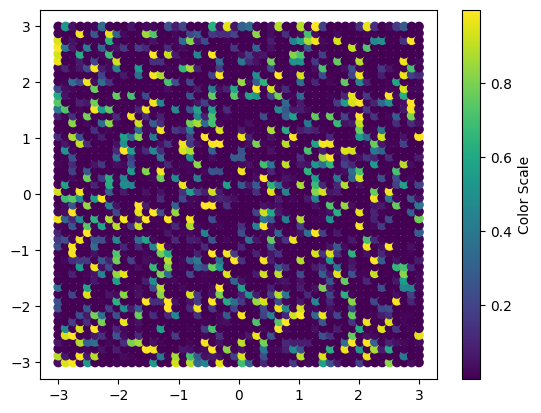

In [286]:

import matplotlib.pyplot as plt

array_2d = y_points.squeeze(axis=-1)  
print(np.shape(array_2d))
softmax = np.exp(array_2d) / np.sum(np.exp(array_2d), axis=1, keepdims=True)
class0_probs = softmax[:,0]

sc = plt.scatter(x_points[:,0,0], x_points[:,1,0], c=class0_probs)
plt.colorbar(sc, label="Color Scale")

In [205]:
int_en = 0
grad_x = np.zeros_like(x) 
for i in range(np.shape(x)[0]):
    grad_x[i] -= sigmoid_prime(x[i]) * b_x[i]
    int_en -= sigmoid(x[i]) * b_x[i]
    for j in range(np.shape(n)[1]):
        grad_x[i] -= sigmoid_prime(x[i]) * sigmoid(n[0, j]) * (w_x[i,j])
        int_en -= w_x[i,j] * sigmoid(x[i]) * sigmoid(n[0, j])
print(int_en)
grad_h = np.zeros_like(n[0,:])
for k in range(np.shape(n)[1]):
    for l in range(np.shape(x)[0]):
        grad_h[k] -= sigmoid_prime(n[0,k]) * sigmoid(x[l]) * (w_x[l, k])


grad_h, grad_x = im.hopfield_interaction_grad(n , x, w_x, b_x, sigmoid, sigmoid_prime, 0, False)
print(im.hopfield_interaction(n , x, w_x, b_x, sigmoid, 0))
print(im.hopfield_2int_grad())


1.2228085529777852
1.2228085529777855


In [ ]:

grad = np.zeros_like(n)
for i in range(n_layers):
    for j in range(n_per_layer):
        grad[i,j] += n[i,j]
        grad[i,j] -= b[i,j] * sigmoid_prime(n[i,j])
        for k in range(n_per_layer):
            if i == 0:
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i+1,k]))*(w[i,j,k] + w[i,k,j])
            elif i == range(n_layers)[-1]:
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i-1,k]))*(w[i-1,j,k] + w[i-1,k,j])
            else:
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i-1,k]))*(w[i-1,j,k] + w[i-1,k,j])
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i+1,k]))*(w[i,j,k] + w[i,k,j])


print(grad)
